# **Project Name**    - Most Streamed Spotify Songs 2023



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**   - Bhumika Maheshwari


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/bhumika0205/Spotify-EDA

# **Problem Statement**


The music industry generates massive amounts of streaming data every day. Understanding the characteristics of highly streamed songs can help artists, producers, and streaming platforms identify trends that contribute to a song's popularity.

This project aims to analyze the Spotify 2023 dataset to discover relationships between song popularity, artist performance, release patterns, playlist appearances, chart rankings, and musical features using exploratory data analysis techniques.

#### **Define Your Business Objective?**

The primary objectives of this project are:

- Analyze the distribution of the most streamed songs.
- Identify the most successful artists.
- Examine how release year affects streaming performance.
- Explore relationships between playlist appearances and stream counts.
- Study the influence of musical attributes such as danceability, energy, valence, and tempo.
- Generate meaningful visualizations to support business insights.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


5. You have to create at least 20 logical & meaningful charts having important insights.

[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]







# ***Let's Begin !***

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## ***1. Know Your Data***

### Import Libraries

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

### Dataset Loading

In [6]:
df = pd.read_csv(
    "/content/drive/MyDrive/Colab Notebooks/spotify-2023.csv",
    encoding="latin-1"
)

### Dataset First View

In [7]:
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


### Dataset Rows & Columns count

In [8]:
df.shape

(953, 24)

### Dataset Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

#### Duplicate Values

In [10]:
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [11]:
df.isnull().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


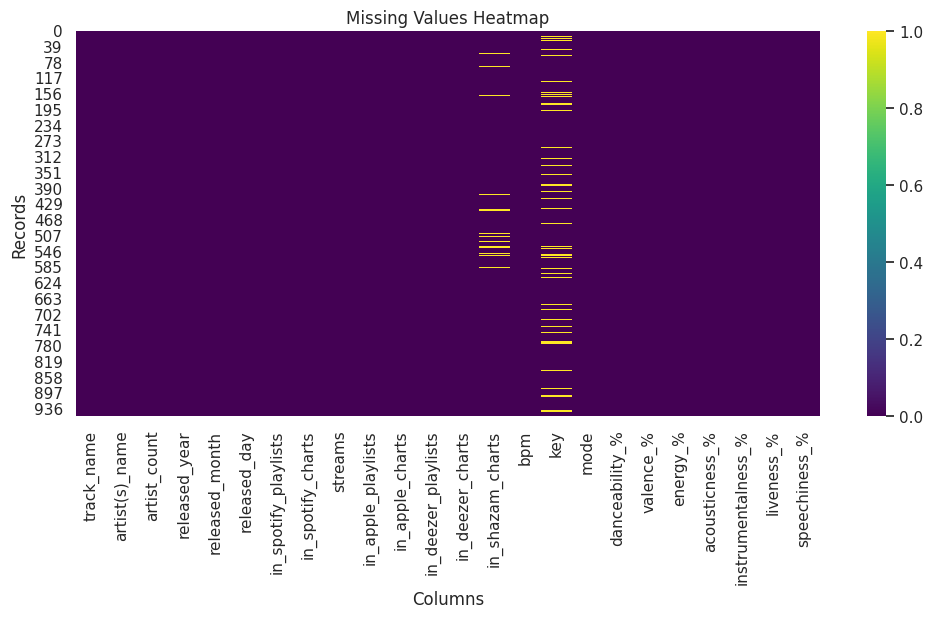

In [12]:
# Visualizing the missing values

plt.figure(figsize=(12,5))
sns.heatmap(df.isnull(), cbar=True, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Records")
plt.show()

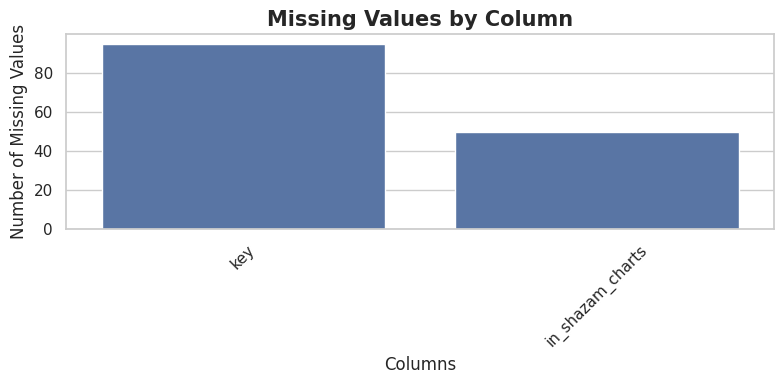

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8,4))

sns.barplot(
    x=missing.index,
    y=missing.values
)

plt.title("Missing Values by Column", fontsize=15, weight="bold")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### What did you know about your dataset?

- The dataset contains **953 songs** and **24 features**, with each row representing a unique song.
- It includes a combination of **categorical** (song name, artist name, key, mode) and **numerical** (streams, playlist counts, chart rankings, musical attributes) variables.
- The data provides information about song popularity across various streaming platforms and playlists, along with audio characteristics such as danceability, energy, valence, speechiness, and tempo.
- Initial inspection indicates that the dataset is largely complete, with only a small number of missing values in a few columns.
- No duplicate records were found, suggesting that each observation represents a distinct song.
- Some columns, such as **`streams`**, are stored as the **object** data type instead of numeric and will require data type conversion before performing statistical analysis.
- Overall, the dataset is well-structured and requires only minimal preprocessing before exploratory data analysis.

## ***2. Understanding Your Variables***

In [14]:
df.columns

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_year',
       'released_month', 'released_day', 'in_spotify_playlists',
       'in_spotify_charts', 'streams', 'in_apple_playlists', 'in_apple_charts',
       'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'bpm',
       'key', 'mode', 'danceability_%', 'valence_%', 'energy_%',
       'acousticness_%', 'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [15]:
df.describe()

,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,in_apple_playlists,in_apple_charts,in_deezer_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000,953.00000,953.000000,953.000000,953.000000,953.000000,953.000000,953.000000
mean,1.556139,2018.238195,6.033578,13.930745,5200.124869,12.009444,67.812172,51.908709,2.666317,122.540399,66.96957,51.431270,64.279119,27.057712,1.581322,18.213012,10.131165
std,0.893044,11.116218,3.566435,9.201949,7897.608990,19.575992,86.441493,50.630241,6.035599,28.057802,14.63061,23.480632,16.550526,25.996077,8.409800,13.711223,9.912888
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.00000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,875.000000,0.000000,13.000000,7.000000,0.000000,100.000000,57.00000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2224.000000,3.000000,34.000000,38.000000,0.000000,121.000000,69.00000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5542.000000,16.000000,88.000000,87.000000,2.000000,140.000000,78.00000,70.000000,77.000000,43.000000,0.000000,24.000000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,672.000000,275.000000,58.000000,206.000000,96.00000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


### Variables Description

* **track_name** : Name of the song
* **artist(s)_name** : Name of the artist(s) of the song
* **artist_count** : Number of artists contributing to the song
* **released_year** : Year when the song was released
* **released_month** : Month when the song was released
* **released_day** : Day of the month when the song was released
* **in_spotify_playlists** : Number of Spotify playlists the song is included in
* **in_spotify_charts** : Presence and rank of the song on Spotify charts
* **streams** : Total number of streams on Spotify
* **in_apple_playlists** : Number of Apple Music playlists the song is included in
* **in_apple_charts** : Presence and rank of the song on Apple Music charts
* **in_deezer_playlists** : Number of Deezer playlists the song is included in
* **in_deezer_charts** : Presence and rank of the song on Deezer charts
* **in_shazam_charts** : Presence and rank of the song on Shazam charts
* **bpm** : Beats per minute, a measure of song tempo
* **key** : Key of the song
* **mode** : Mode of the song (major or minor)
* **danceability_%** : Percentage indicating how suitable the song is for dancing
* **valence_%** : Positivity of the song's musical content
* **energy_%** : Perceived energy level of the song
* **acousticness_%** : Amount of acoustic sound in the song
* **instrumentalness_%** : Amount of instrumental content in the song
* **liveness_%** : Presence of live performance elements
* **speechiness_%** : Amount of spoken words in the song

### Check Unique Values for each variable.

In [ ]:
df.nunique()

,0
track_name,943
artist(s)_name,645
artist_count,8
released_year,50
released_month,12
released_day,31
in_spotify_playlists,879
in_spotify_charts,82
streams,949
in_apple_playlists,234


## 3. ***Data Wrangling***

### Data Wrangling Code

In [16]:
df_clean = df.copy()

In [19]:
#checking for duplicate records
duplicate_count = df_clean.duplicated().sum()
print("Duplicate Records:", duplicate_count)

Duplicate Records: 0


In [21]:
#checking for missing data
missing_values = df_clean.isnull().sum()
missing_values[missing_values > 0]

,0
in_shazam_charts,50
key,95


In [24]:
# Fill missing values in 'key' with the mode since it is a categorical column
df_clean["key"] = df_clean["key"].fillna(df_clean["key"].mode()[0])

In [36]:
# Converting 'in_shazam_charts' from object to numeric
df_clean["in_shazam_charts"] = pd.to_numeric(
    df_clean["in_shazam_charts"],
    errors="coerce"
)

In [35]:
# Convert "in_shazam_charts" to integer
df_clean["in_shazam_charts"] = df_clean["in_shazam_charts"].fillna(0)
df_clean["in_shazam_charts"] = df_clean["in_shazam_charts"].astype(int)
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      953 non-null    int64 
 14  bpm                   953 non-null    int64 
 15  key                   953 non-null    ob

In [41]:
#checking if any 'streams' is null value
pd.to_numeric(df_clean["streams"], errors="coerce").isnull().sum()

np.int64(0)

In [39]:
# Remove the corrupted row with an invalid stream value
df_clean = df_clean[
    pd.to_numeric(df_clean["streams"], errors="coerce").notnull()
]

# Convert the streams column to numeric
df_clean["streams"] = pd.to_numeric(df_clean["streams"])

In [45]:
#removing ',' from "in_deezer_playlists" and converting to int data type
df_clean["in_deezer_playlists"] = (
    df_clean["in_deezer_playlists"]
    .str.replace(",", "", regex=False)
)

df_clean["in_deezer_playlists"] = pd.to_numeric(
    df_clean["in_deezer_playlists"]
)

In [47]:
# Final verification of cleaned dataset
df_clean.info()
print("Dataset Shape:", df_clean.shape)
print("\nMissing Values:\n")
print(df_clean.isnull().sum())
print("\nDuplicate Records:", df_clean.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 952 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            952 non-null    object
 1   artist(s)_name        952 non-null    object
 2   artist_count          952 non-null    int64 
 3   released_year         952 non-null    int64 
 4   released_month        952 non-null    int64 
 5   released_day          952 non-null    int64 
 6   in_spotify_playlists  952 non-null    int64 
 7   in_spotify_charts     952 non-null    int64 
 8   streams               952 non-null    int64 
 9   in_apple_playlists    952 non-null    int64 
 10  in_apple_charts       952 non-null    int64 
 11  in_deezer_playlists   952 non-null    int64 
 12  in_deezer_charts      952 non-null    int64 
 13  in_shazam_charts      952 non-null    int64 
 14  bpm                   952 non-null    int64 
 15  key                   952 non-null    object


### What all manipulations have you done and insights you found?

* Created a working copy of the original dataset to preserve the raw data.
* Verified that no duplicate records were present.
* Handled missing values in the 'key' column by replacing missing values with mode value.
* Handled missing value of 'in_shazam_charts' columns using appropriate imputation methods and converted it to int data type.
* Identified and removed one corrupted record with an invalid streams value,as it could not be converted to a numeric format.
* Converted the 'streams' and 'in_deezer_playlists' columns to the appropriate numeric data type.
* Verified that the cleaned dataset contains no missing values in the processed columns and is ready for exploratory data analysis.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Top 10 Most streamed songs

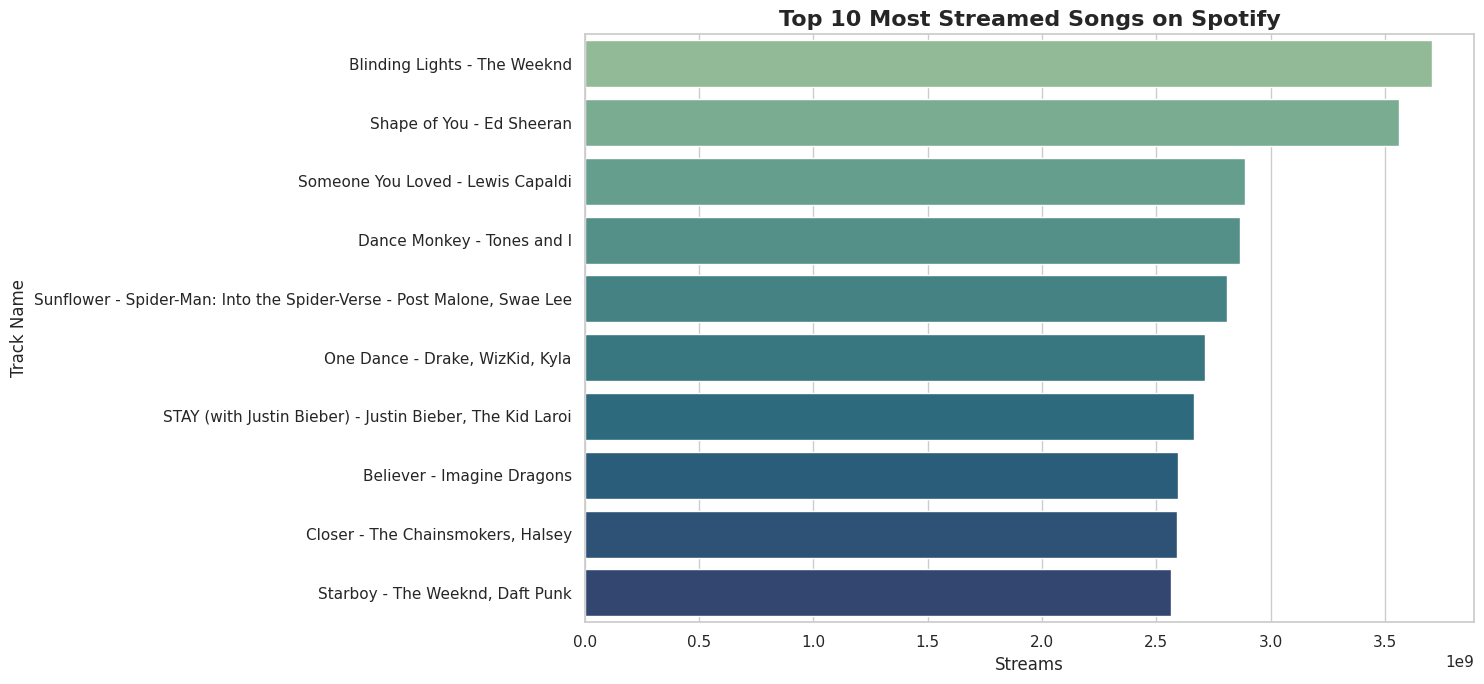

In [65]:
# Chart - 1 visualization code

# Top 10 Most streamed songs

top10_songs = df_clean.sort_values(by="streams", ascending=False).head(10)
top10_songs["Song"] = (
    top10_songs["track_name"] +
    " - " +
    top10_songs["artist(s)_name"]
)

plt.figure(figsize=(15,7))

sns.barplot(
    data=top10_songs,
    x="streams",
    y="Song",
    hue="track_name",
    palette="crest",
    legend=False
)

plt.title("Top 10 Most Streamed Songs on Spotify", fontsize=16, fontweight="bold")
plt.xlabel("Streams", fontsize=12)
plt.ylabel("Track Name", fontsize=12)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it is the most effective way to compare the stream counts of the top 10 songs. Since song titles can be long, a horizontal layout provides better readability than a vertical bar chart. It also allows viewers to quickly identify and compare the highest-streamed songs without label overlap.

##### 2. What is/are the insight(s) found from the chart?

Insights
* A small number of songs dominate total Spotify streams, indicating that streaming popularity is highly concentrated among a few tracks.
* The difference in stream counts between the highest-ranked and lower-ranked songs in the top 10 highlights varying levels of audience engagement.
* The most-streamed songs have achieved billions of streams, reflecting their global popularity and long-term listener retention.
* These songs can be considered benchmark tracks for understanding successful music trends on the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights help identify the songs that generate the highest listener engagement. Spotify can use this information to improve playlist recommendations, promote similar artists, enhance personalized music suggestions, and support marketing campaigns. Record labels can also study the characteristics of these successful songs to understand listener preferences and improve future music releases.

#### Chart - 2 Top 10 Most streamed artists

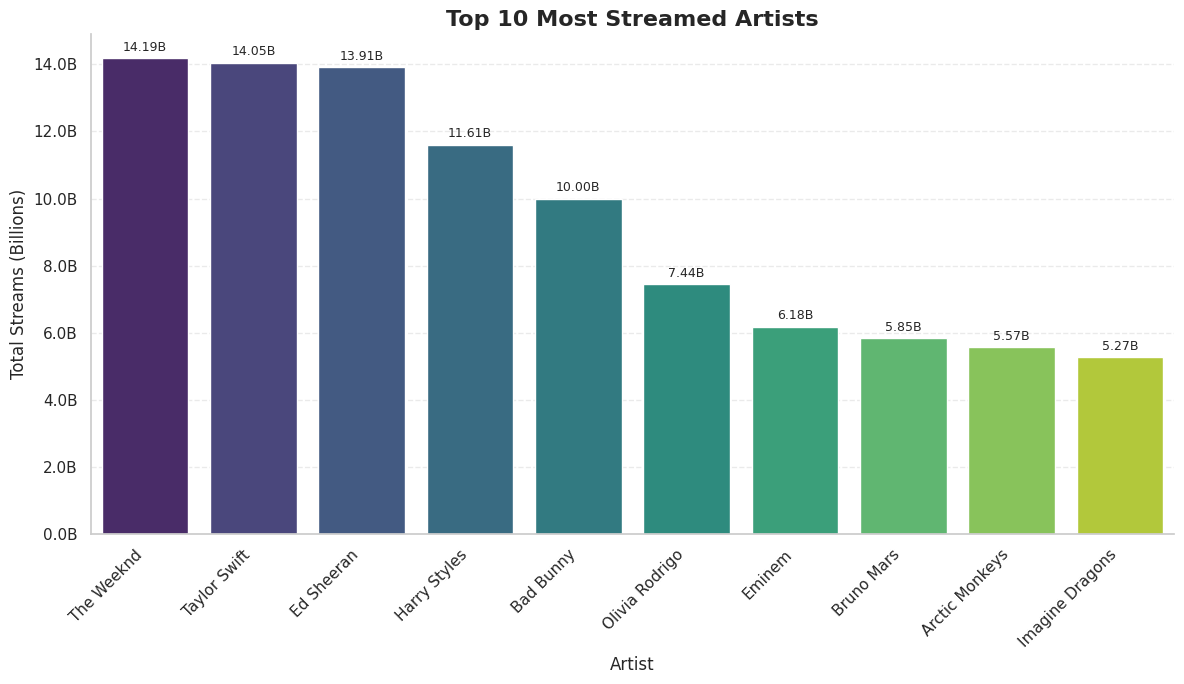

In [68]:
# Chart - 2 visualization code

# Top 10 Most Streamed Artists

top_artists = (
    df_clean.groupby("artist(s)_name")["streams"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,7))

ax = sns.barplot(
    x=top_artists.index,
    y=top_artists.values,
    hue=top_artists.index,
    palette="viridis",
    legend=False
)

plt.title(
    "Top 10 Most Streamed Artists",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Artist", fontsize=12)
plt.ylabel("Total Streams (Billions)", fontsize=12)

plt.xticks(rotation=45, ha="right")

# Format y-axis in billions
from matplotlib.ticker import FuncFormatter

formatter = FuncFormatter(lambda x, pos: f'{x/1e9:.1f}B')
plt.gca().yaxis.set_major_formatter(formatter)

# Display values on bars
for container in ax.containers:
    labels = [f'{v.get_height()/1e9:.2f}B' for v in container]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.grid(axis="y", linestyle="--", alpha=0.4)

sns.despine()

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A vertical bar chart was chosen because it is the most suitable visualization for comparing the total stream counts of different artists. It clearly highlights ranking differences and allows easy comparison of artist popularity based on cumulative streams.

##### 2. What is/are the insight(s) found from the chart?

* A small number of artists contribute a significant share of the total streams, indicating their strong global popularity.
* The top-ranked artists have accumulated billions of streams, reflecting consistent listener engagement across multiple songs.
* There is a noticeable difference in stream counts between the highest-ranked artist and the remaining artists, showing that popularity is not evenly distributed.
* Artists with consistently high streams are likely to have a stronger influence on current music trends and listener preferences.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positibe business impact can be this help Spotify and record labels identify artists with consistently popular music. These artists can be used for featured playlists, promotional campaigns, exclusive releases

But the chart indicates that a small number of artists dominate the dataset. Continuously promoting only these artists may reduce visibility for emerging musicians, limiting content diversity. Over time, this could decrease listener discovery of new artists and reduce the variety of music consumed on the platform.

#### Chart - 3

In [ ]:
# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

In [ ]:
# Chart - 4 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

In [ ]:
# Chart - 5 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

In [ ]:
# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

In [ ]:
# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [ ]:
# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 9

In [ ]:
# Chart - 9 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 10

In [ ]:
# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 11

In [ ]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [ ]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [ ]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [ ]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [ ]:
# Pair Plot visualization code

In [ ]:
sns.pairplot(df)

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Answer Here.

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***